# Exploratory Data Analysis (EDA)

## Explainable Credit Risk Assessment System

This notebook performs an in-depth exploratory data analysis (EDA) to understand credit risk patterns, class imbalance, and key drivers of loan default before model development.

## Dataset
This project uses the Credit Risk Dataset from Kaggle.

Source: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

## 1. Dataset Overview

The dataset contains applicant demographics, employment details, loan characteristics, and historical credit behavior.

**Target Variable:** `loan_status` (0 = Non-default, 1 = Default)

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (update path if needed)
df = pd.read_csv('/content/credit_risk_dataset.csv')

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


((32581, 12), None)

## 2. Target Variable Analysis

Understanding class distribution is critical due to imbalance in credit risk problems.

In [6]:
df['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
0,0.781836
1,0.218164


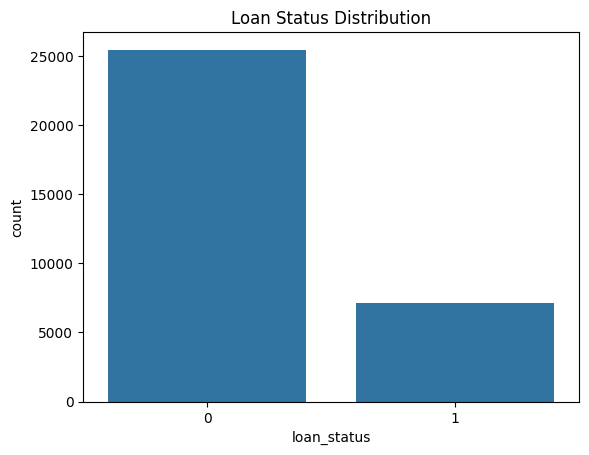

In [7]:
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

**Insight:** The dataset is imbalanced, reflecting real-world lending scenarios. Accuracy alone is not sufficient; ROC-AUC and Recall are preferred metrics.

## 3. Missing Value Analysis

In [8]:
df.isnull().mean().sort_values(ascending=False)

,0
loan_int_rate,0.095639
person_emp_length,0.027470
person_income,0.000000
person_age,0.000000
person_home_ownership,0.000000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_status,0.000000
loan_percent_income,0.000000


**Observation:** Missing values are mainly present in employment length and interest rate. Median imputation will be used later.

## 4. Numerical Feature Analysis

In [9]:
num_cols = ['person_age','person_income','person_emp_length','loan_amnt',
            'loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

df[num_cols].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000


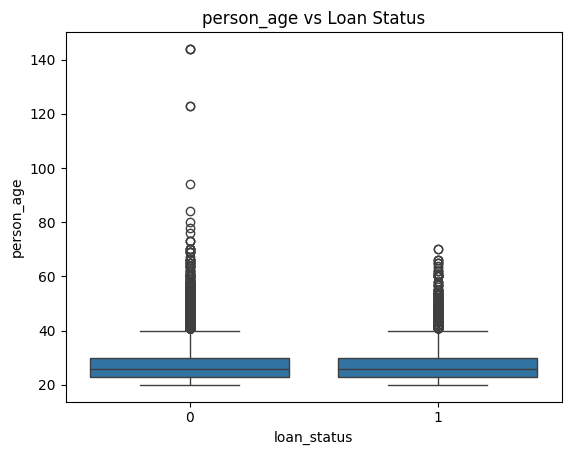

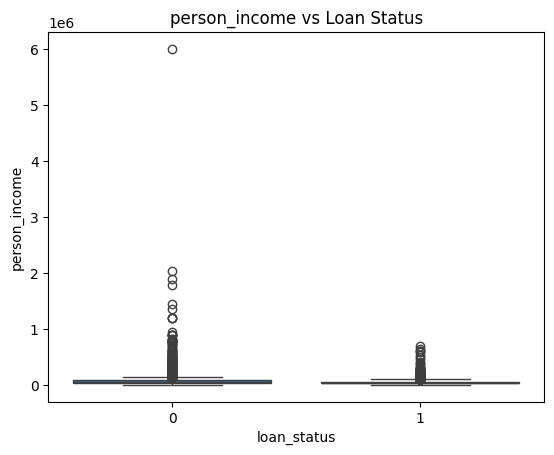

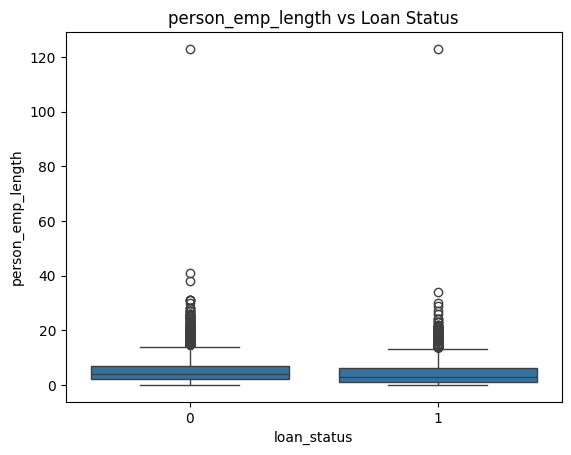

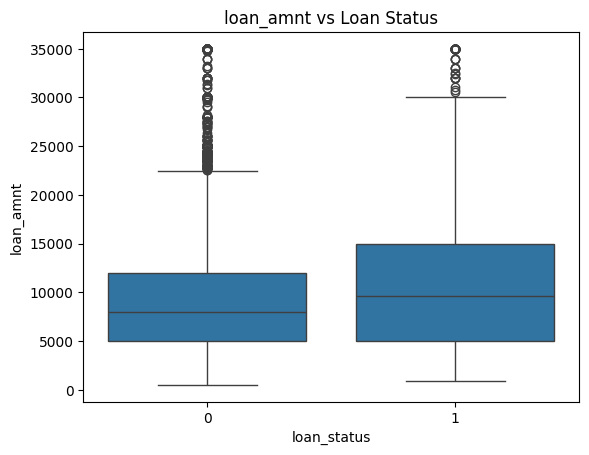

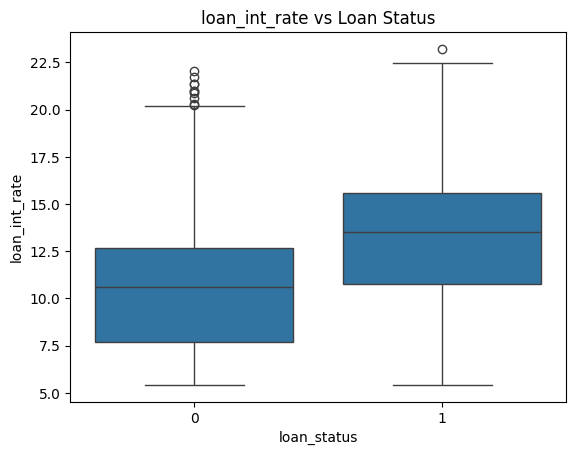

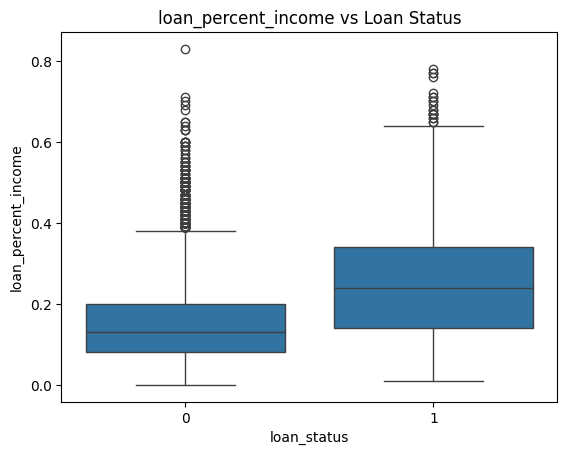

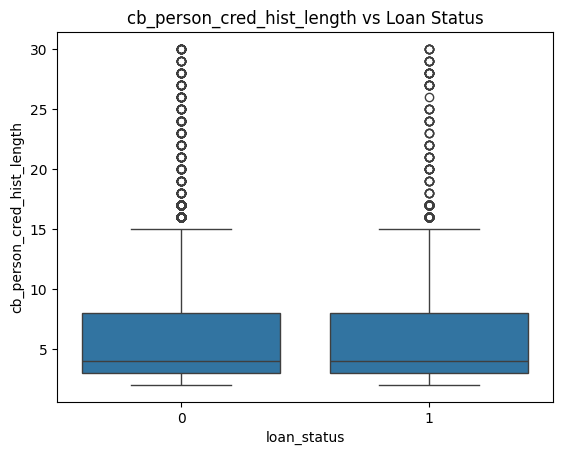

In [10]:
for col in num_cols:
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f'{col} vs Loan Status')
    plt.show()

**Insight:** Loan burden (`loan_percent_income`) and interest rate show strong differences between defaulters and non-defaulters.

## 5. Categorical Feature Analysis

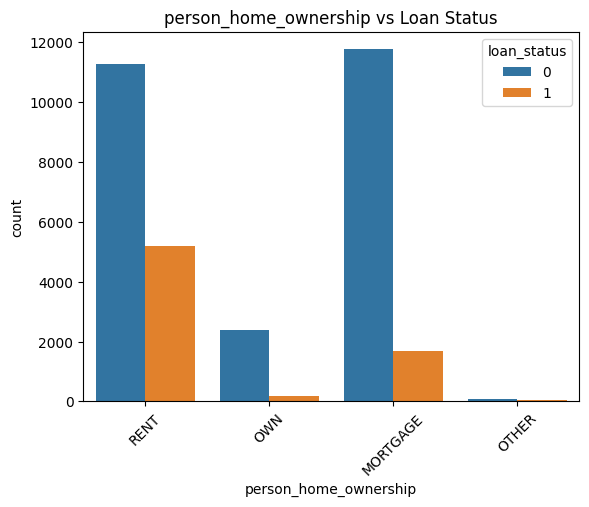

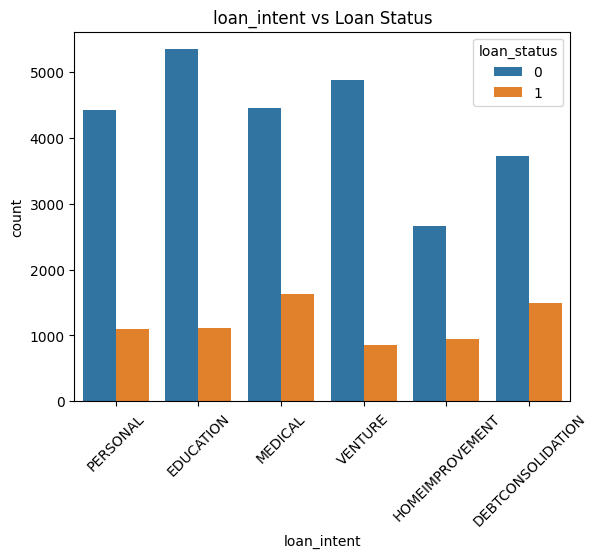

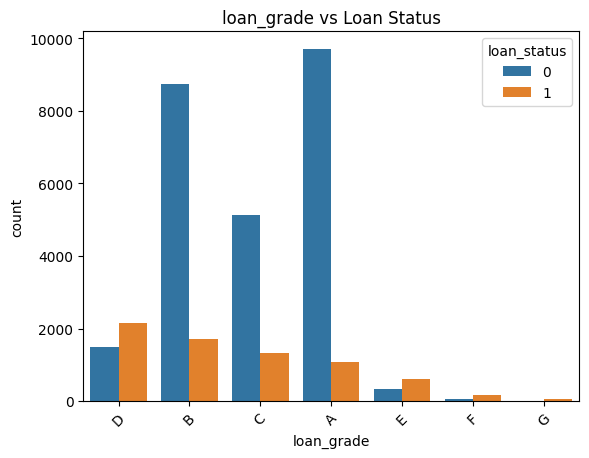

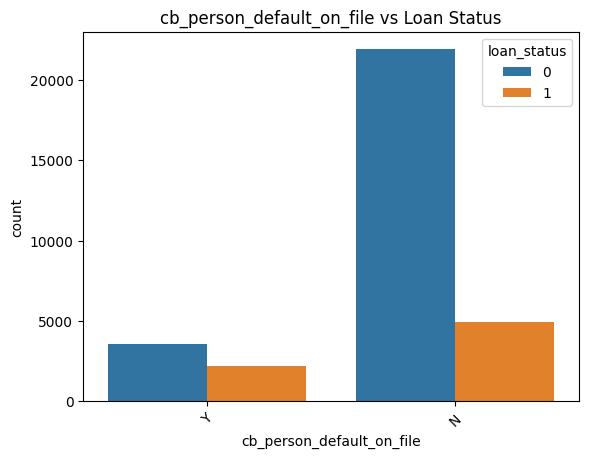

In [11]:
cat_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

for col in cat_cols:
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Loan Status')
    plt.show()

**Insight:** Historical default records and lower loan grades are strong indicators of higher credit risk.

## 6. Correlation Analysis

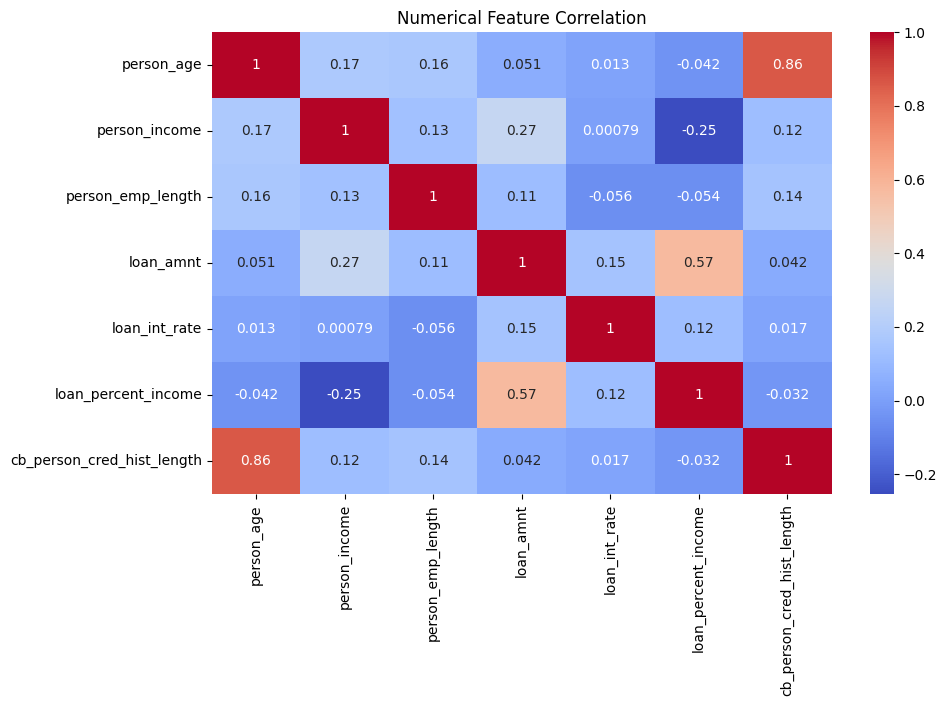

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Numerical Feature Correlation')
plt.show()

**Insight:** No severe multicollinearity detected. Tree-based models can handle moderate correlations.

## 7. EDA Summary

- Dataset shows realistic class imbalance
- Loan burden and interest rate are key risk drivers
- Past default behavior strongly correlates with future defaults
- Data quality is sufficient for modeling

**Conclusion:** EDA confirms the suitability of the dataset for credit risk modeling using explainable ML techniques.